## How to extract matplotlib elements

### the model
* ggplot object
   ↓
* plotnine build pipeline (scales, stats, coord)
   ↓
* Matplotlib Artists (Axes, Lines, Patches, Text, Collections)


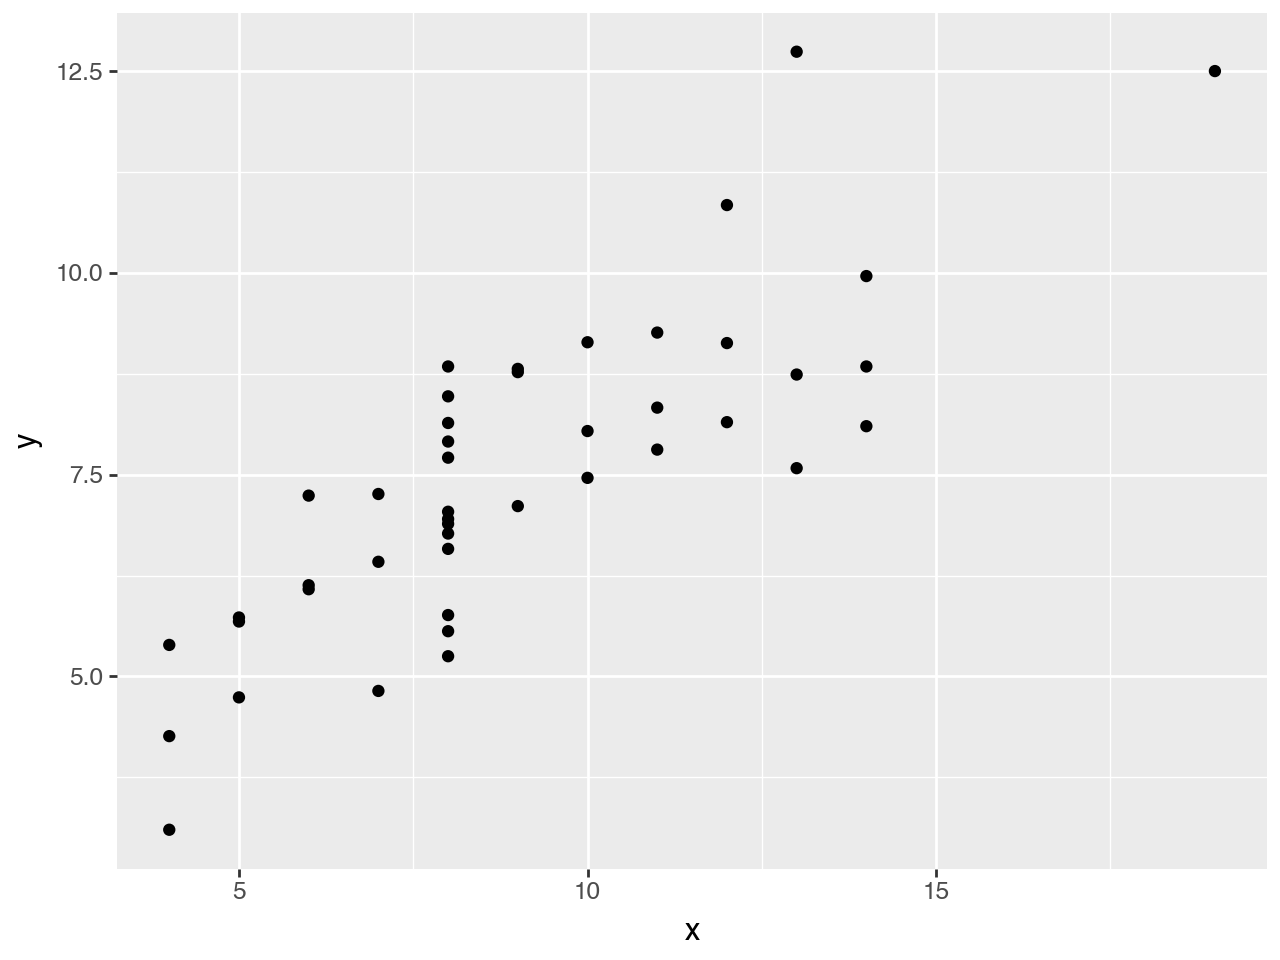

In [19]:
import matplotlib.pyplot as plt
import numpy as np
# Set random seed for reproducibility
np.random.seed(2026)

from plotnine import * 
from plotnine.data import anscombe_quartet 
#for artist in ax.get_children(): print(type(artist))


p = ggplot(anscombe_quartet, aes(x="x", y="y")) + geom_point()
p

### Rebuild fully in matplotlib
doesnt look quite the same

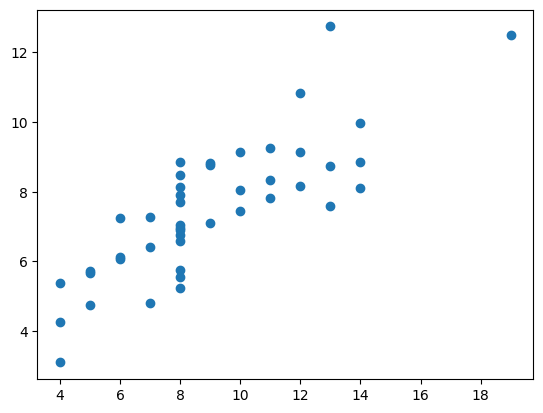

In [16]:
fig = p.draw()
ax = fig.axes[0]

scatter = ax.collections[0]
xy = scatter.get_offsets()

plt.figure()
plt.scatter(xy[:, 0], xy[:, 1])
plt.show()


<Axes.ArtistList of 1 collections>
<Axes.ArtistList of 0 lines>


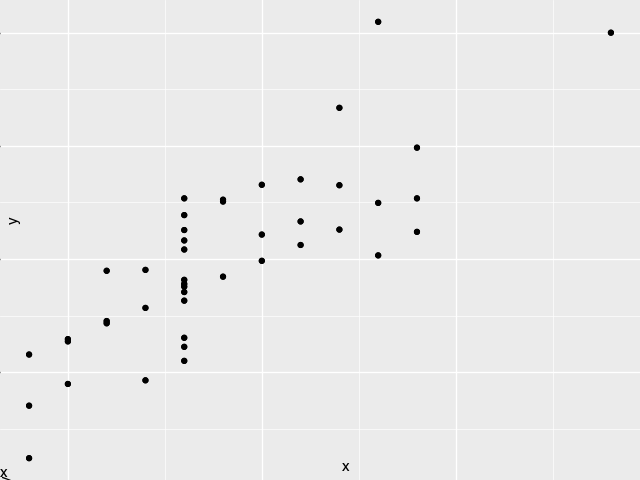

In [21]:
fig = p.draw()
ax = fig.axes[0]

ax.set_title("Pure Matplotlib Now")
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.grid(True)

fig.set_size_inches(8, 6)
#fig.tight_layout()

print(ax.collections)     # matplotlib artists
print(ax.lines)

plt.show()
p

### trying to access built data

In [24]:
#does not work
fig = p.draw()

built = p._build()   # build object is returned in recent versions

print(built.data)
print(built.layout)
print(built.scales)

AttributeError: 'NoneType' object has no attribute 'data'

In [22]:
#does not work
from plotnine.ggplot import ggplot
# Build the plot (computes stats, scales, layout)
fig = p.draw()

built = p._build()
if built is None:
    built = p._built  # fallback for some versions

print(built.data)


AttributeError: 'ggplot' object has no attribute '_built'

In [11]:
fig = p.draw()
ax = fig.axes[0]

# Extract scatter data from matplotlib
collection = ax.collections[0]
offsets = collection.get_offsets()

print(offsets[:5])

[[10.0 8.04]
 [8.0 6.95]
 [13.0 7.58]
 [9.0 8.81]
 [11.0 8.33]]


### extract data via matplotlib

In [23]:
#works
fig = p.draw()
ax = fig.axes[0]

# For geom_point
scatter = ax.collections[0]
offsets = scatter.get_offsets()

print(offsets[:10])


[[10.0 8.04]
 [8.0 6.95]
 [13.0 7.58]
 [9.0 8.81]
 [11.0 8.33]
 [14.0 9.96]
 [6.0 7.24]
 [4.0 4.26]
 [12.0 10.84]
 [7.0 4.82]]
